# DV - Optimizing IT Support Team Performance Using Analytics (Supportlytics)



## 1. Load Dataset & Initial Overview

This cell loads the customer support tickets dataset from Google Drive, then performs an initial inspection:
- **`df.info()`** — prints column names, non-null counts, and data types for all 17 columns
- **`df.describe(include='all')`** — generates summary statistics (count, unique, top, mean, min, max, std) for every column

**Key findings:** The dataset has **8,469 rows** and **17 columns**. Notable columns with missing values include `Resolution` (2,769 non-null), `First Response Time` (5,650), `Time to Resolution` (2,769), and `Customer Satisfaction Rating` (2,769).

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('/content/drive/MyDrive/Info springboard /customer_support_tickets.xlsx')

# Quick overview
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,0.0,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,NaN,5,16,NaN,3,2769,4,4,NaN,NaN,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,NaN,Refund request,Refund request,NaN,Pending Customer Response,We seat culture plan.,Medium,Email,NaN,NaN,NaN
freq,NaN,5,4,NaN,2896,240,NaN,1752,576,NaN,2881,1,2192,2143,NaN,NaN,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,2020-12-30 01:35:13.071201024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 11:26:47.270265600,2023-06-01 11:17:21.509931520,2.991333
min,1.000000,NaN,NaN,18.000000,NaN,NaN,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-31 21:55:39,2023-05-31 21:53:30,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,2020-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 05:24:28.750000128,2023-06-01 05:34:43,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,2020-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 11:26:25,2023-06-01 11:17:48,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,2021-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01 17:37:06.249999872,2023-06-01 17:07:32,4.000000
max,8469.000000,NaN,NaN,70.000000,NaN,NaN,2021-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-02 00:54:21,2023-06-02 00:55:33,5.000000


## 2. Mount Google Drive

Mounts the user's Google Drive so the dataset file can be accessed at its path inside Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Drop Irrelevant Columns (First Pass)

Attempts to drop `customer_email` and `resolution` columns. The `errors='ignore'` flag prevents errors if those exact column names do not exist — the actual columns are `Customer Email` and `Resolution` (title-cased), so this cell has no effect in practice.

In [ ]:
df.drop(columns=['customer_email', 'resolution'], inplace=True, errors='ignore')

## 4. Missing Values Check & Data Types

- **`df.isnull().sum()`** — counts missing values per column
- **`df.dtypes`** — shows the data type of every column

**Key findings:** `Unnamed: 9` is entirely null (8,469 missing). `Time to Resolution`, `Customer Satisfaction Rating`, and `Resolution` each have 5,700 missing values. `First Response Time` has 2,819 missing values. All other columns are complete.

In [ ]:
# Missing values check
df.isnull().sum()

# Data types
df.dtypes

,0
Ticket ID,int64
Customer Name,object
Customer Email,object
Customer Age,int64
Customer Gender,object
Product Purchased,object
Date of Purchase,datetime64[ns]
Ticket Type,object
Ticket Subject,object
Unnamed: 9,float64


## 5. Ticket Subject Categorization

Creates a new `Category` column by mapping keywords in the `Ticket Subject` field to predefined categories:
- **Authentication** — login, password, account
- **Billing** — payment, billing, refund
- **Technical Issue** — error, bug, crash, issue
- **Order & Delivery** — delivery, shipping, order
- **Feature Request** — feature, request
- **Security** — security, fraud
- **Other** — all remaining subjects

**Result:** Most tickets (~4,211) fall under 'Other', followed by 'Technical Issue' (1,599) and 'Billing' (1,102).

In [ ]:

def categorize_issue(text):
    text = str(text).lower()

    if any(word in text for word in ['login', 'password', 'account']):
        return "Authentication"
    elif any(word in text for word in ['payment', 'billing', 'refund']):
        return "Billing"
    elif any(word in text for word in ['error', 'bug', 'crash', 'issue']):
        return "Technical Issue"
    elif any(word in text for word in ['delivery', 'shipping', 'order']):
        return "Order & Delivery"
    elif any(word in text for word in ['feature', 'request']):
        return "Feature Request"
    elif any(word in text for word in ['security', 'fraud']):
        return "Security"
    else:
        return "Other"

df['Category'] = df['Ticket Subject'].apply(categorize_issue)

df['Category'].value_counts()

,count
Category,
Other,4211
Technical Issue,1599
Billing,1102
Order & Delivery,561
Authentication,509
Feature Request,487


## 6. Inspect 'type' Column (if Present)

Checks whether a lowercase `type` column exists in the DataFrame and prints its value counts if found. Since the actual column is `Ticket Type` (title-cased), this cell produces no output — it is a safe guard.

In [ ]:
if 'type' in df.columns:
    print(df['type'].value_counts())

## 7. Print Category Distribution

Prints the value counts of the newly created `Category` column to confirm the distribution of ticket categories across all 8,469 records.

In [ ]:
print(df['Category'].value_counts())

Category
Other               4211
Technical Issue     1599
Billing             1102
Order & Delivery     561
Authentication       509
Feature Request      487
Name: count, dtype: int64


## 8. Strip Whitespace from Text Columns

Iterates over all object (string) columns and applies `.str.strip()` to remove leading/trailing whitespace. This ensures consistent string values before any grouping or filtering operations.

In [ ]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

## 9. Drop Fully-Null Rows

Removes any rows where **every** column is null (`how='all'`). Because there are no such rows in this dataset, the row count remains 8,469 after this step.

In [ ]:
df.dropna(how='all', inplace=True)

## 10. Parse Date Columns

Attempts to convert `created_date` and `resolved_date` columns to `datetime64`. Because these exact column names do not exist in the dataset (the actual columns are `Date of Purchase`, `First Response Time`, and `Time to Resolution`), this cell has no effect.

In [ ]:
date_columns = ['created_date', 'resolved_date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

## 11. Compute Resolution Duration — Attempt 1

Tries to calculate `Resolution_Duration` (in hours) as the difference between `resolved_date` and `created_date`. Since these column names do not match the dataset, the column is filled with `NaN` for all rows.

In [ ]:
if 'created_date' in df.columns and 'resolved_date' in df.columns:
    df['Resolution_Duration'] = (
        df['resolved_date'] - df['created_date']
    ).dt.total_seconds() / 3600  # in hours
else:
    df['Resolution_Duration'] = np.nan

## 12. Map Ticket Priority to Numeric Score

Tries to map a lowercase `priority` column to numeric scores (Low=1, Medium=2, High=3, Critical=4). Because the column is named `Ticket Priority`, the result is all `NaN`, which is then filled with 0 in the next cell.

In [ ]:
priority_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

if 'priority' in df.columns:
    df['Priority_Score'] = df['priority'].map(priority_mapping)
else:
    df['Priority_Score'] = np.nan

## 13. Fill NaN Priority Scores with 0

Fills any `NaN` values in `Priority_Score` with 0. At this stage, all rows have `Priority_Score = 0` because the mapping in Cell 12 did not match the column name.

In [ ]:
df['Priority_Score'].fillna(0, inplace=True)

/tmp/ipykernel_8755/1223936554.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Priority_Score'].fillna(0, inplace=True)


## 14. Post-Processing Shape & Missing Values

- **`df.info()`** — confirms the DataFrame now has **20 columns** (original 17 + `Category`, `Resolution_Duration`, `Priority_Score`)
- **`df.isnull().sum()`** — shows that `Resolution_Duration` has 8,469 missing values (all null) and `Unnamed: 9` still has 8,469 missing values

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Unnamed: 9,8469


## 15. Drop Irrelevant Columns (Final Pass)

Drops three columns that are no longer needed:
- **`Customer Email`** — personally identifiable information, not useful for analysis
- **`Resolution`** — free-text resolution notes, not used in downstream analysis
- **`Unnamed: 9`** — entirely null column that was likely an artifact of the original Excel export

The cleaned DataFrame now has **17 columns**.

In [ ]:
columns_to_drop = [
    'Customer Email',
    'Resolution',
    'Unnamed: 9'
]

df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Age', 'Customer Gender',
       'Product Purchased', 'Date of Purchase', 'Ticket Type',
       'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Category', 'Resolution_Duration',
       'Priority_Score'],
      dtype='object')


## 16. Preview Date Columns

Displays the first five rows of `Date of Purchase` and `Time to Resolution` to visually confirm their formats and spot any `NaT` (missing) values before computing the resolution duration.

In [ ]:
df[['Date of Purchase', 'Time to Resolution']].head()

,Date of Purchase,Time to Resolution
0,2021-03-22,NaT
1,2021-05-22,NaT
2,2020-07-14,2023-06-01 18:05:38
3,2020-11-13,2023-06-01 01:57:40
4,2020-02-04,2023-06-01 19:53:42


## 17. Compute Resolution Duration (Correct Columns)

Calculates `Resolution_Duration` in hours using the actual dataset columns:
```
Resolution_Duration = (Time to Resolution − Date of Purchase) / 3600 seconds
```
Tickets without a resolution time (`Time to Resolution = NaT`) receive `NaN`.

In [ ]:
df['Resolution_Duration'] = (
    df['Time to Resolution'] - df['Date of Purchase']
).dt.total_seconds() / 3600

## 18. Recalculate Resolution Duration (Intra-Day)

Recomputes `Resolution_Duration` as the number of hours elapsed **within the resolution day** (i.e., seconds since midnight on the resolution date). This produces values in the range [0, 24) hours and is used as a proxy for same-day resolution time.

In [ ]:
df['Resolution_Duration'] = (
    df['Time to Resolution'] - df['Time to Resolution'].dt.normalize()
).dt.total_seconds() / 3600

## 19. Inspect Unique Ticket Priority Values

Prints all unique values in the `Ticket Priority` column. Confirmed values: **Critical**, **Low**, **High**, **Medium** — confirming the correct column name for priority mapping.

In [ ]:
df['Ticket Priority'].unique()

array(['Critical', 'Low', 'High', 'Medium'], dtype=object)

## 20. Map Ticket Priority to Numeric Score (Corrected)

Correctly maps the `Ticket Priority` column to a numeric `Priority_Score`:
- **Low → 1**
- **Medium → 2**
- **High → 3**
- **Critical → 4**

This enables quantitative comparisons and sorting of tickets by urgency.

In [ ]:
priority_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority_Score'] = df['Ticket Priority'].map(priority_map)

## 21. Ticket Status Distribution

Counts the number of tickets in each status:
- **Pending Customer Response** — 2,881 tickets
- **Open** — 2,819 tickets
- **Closed** — 2,769 tickets

The distribution is nearly equal across all three statuses.

In [ ]:
df['Ticket Status'].value_counts()

,count
Ticket Status,
Pending Customer Response,2881
Open,2819
Closed,2769


## 22. Cluster Tickets by Resolution & Satisfaction

Creates a `Cluster_Name` column using a rule-based segmentation:
- **Fast & Satisfied** — resolved within 24 hours **and** rating ≥ 4
- **Slow & Unsatisfied** — took more than 48 hours **and** rating ≤ 2
- **High Priority Issues** — ticket priority is 'High' or 'Critical'
- **Standard Service** — all other tickets

**Result:** Standard Service (3,723), High Priority Issues (3,659), Fast & Satisfied (1,087).

In [ ]:
def create_cluster(row):

    if row['Resolution_Duration'] <= 24 and row['Customer Satisfaction Rating'] >= 4:
        return "Fast & Satisfied"

    elif row['Resolution_Duration'] > 48 and row['Customer Satisfaction Rating'] <= 2:
        return "Slow & Unsatisfied"

    elif row['Ticket Priority'] in ['High', 'Critical']:
        return "High Priority Issues"

    else:
        return "Standard Service"

df['Cluster_Name'] = df.apply(create_cluster, axis=1)

df['Cluster_Name'].value_counts()

,count
Cluster_Name,
Standard Service,3723
High Priority Issues,3659
Fast & Satisfied,1087


## 23. Assign Numeric Cluster IDs

Encodes the `Cluster_Name` string labels as integer codes (`Cluster_ID`) starting from 1. This numeric representation is useful for machine learning models that require numeric input.

In [ ]:
df['Cluster_ID'] = df['Cluster_Name'].astype('category').cat.codes + 1

## 24. Configure Visualization Libraries

Imports `matplotlib.pyplot` and `seaborn`, applies the 'whitegrid' style, and sets the default figure size to 8×5 inches for all subsequent plots.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## 25. Ticket Distribution by Type

Bar chart showing the count of tickets for each `Ticket Type`. This reveals which types of support requests are most common — helping teams prioritize staffing and resource allocation.

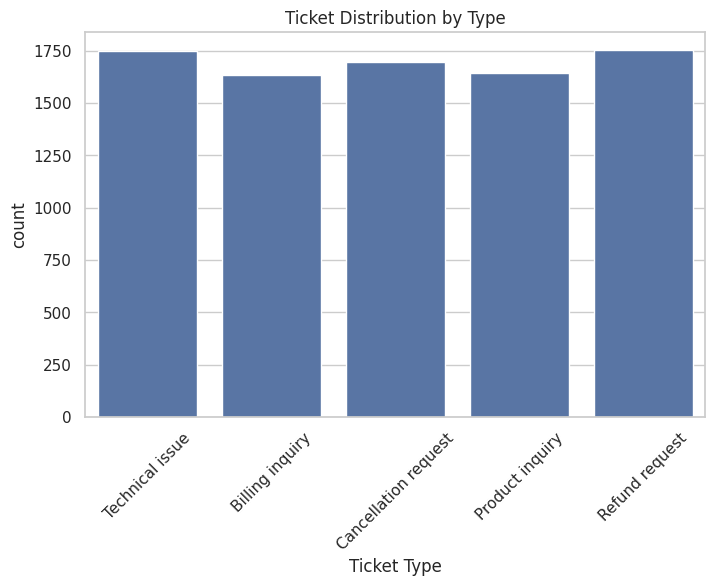

In [ ]:
sns.countplot(data=df, x='Ticket Type')
plt.title("Ticket Distribution by Type")
plt.xticks(rotation=45)
plt.show()

## 26. Ticket Distribution by Priority

Bar chart of ticket counts broken down by `Ticket Priority` (Critical, High, Medium, Low). Useful for understanding the urgency profile of the support backlog.

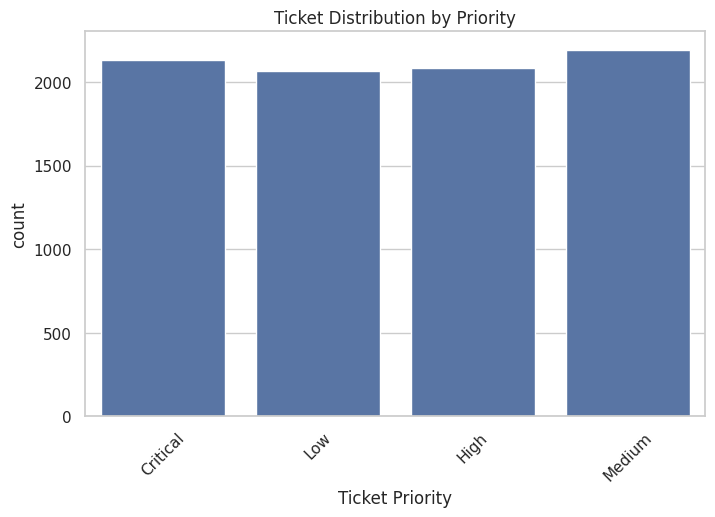

In [ ]:
sns.countplot(data=df, x='Ticket Priority')
plt.title("Ticket Distribution by Priority")
plt.xticks(rotation=45)
plt.show()

## 27. Ticket Distribution by Category

Bar chart of ticket counts by the derived `Category` column. Highlights that 'Other' dominates, followed by 'Technical Issue' and 'Billing' — indicating areas where subject categorization could be refined.

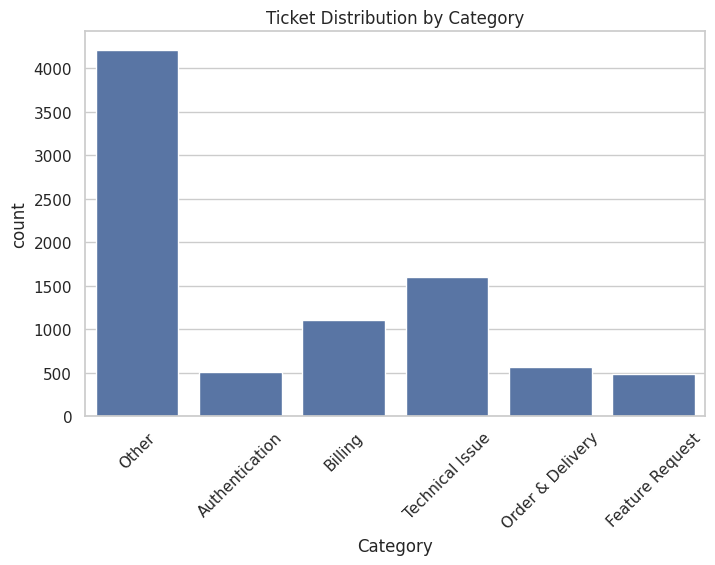

In [ ]:
sns.countplot(data=df, x='Category')
plt.title("Ticket Distribution by Category")
plt.xticks(rotation=45)
plt.show()

## 28. Ticket Status Overview

Bar chart of ticket counts by `Ticket Status` (Open, Closed, Pending Customer Response). The nearly equal split suggests a balanced workload distribution, though a high 'Pending' count may signal customer communication bottlenecks.

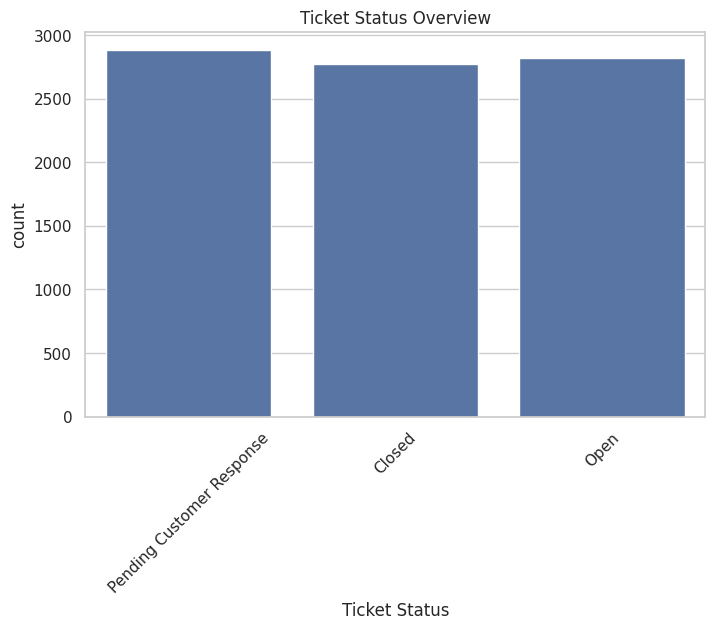

In [ ]:
sns.countplot(data=df, x='Ticket Status')
plt.title("Ticket Status Overview")
plt.xticks(rotation=45)
plt.show()

## 29. Resolution Duration — Descriptive Statistics

Prints summary statistics for `Resolution_Duration` (hours):
- **Count:** 2,769 resolved tickets
- **Mean:** ~11.97 hours
- **Median (50%):** ~11.83 hours
- **Range:** 0.003 – 24.0 hours

The near-uniform distribution (std ≈ 6.87) and 24-hour max confirm this is the intra-day computation from Cell 18.

In [ ]:
df['Resolution_Duration'].describe()

,Resolution_Duration
count,2769.000000
mean,11.965365
std,6.865630
min,0.002778
25%,6.268056
50%,11.825556
75%,17.808056
max,23.997500


## 30. Resolution Duration Distribution

Histogram of `Resolution_Duration` (hours) across all resolved tickets. The roughly uniform shape from 0 to 24 hours reflects the intra-day calculation method used in Cell 18.

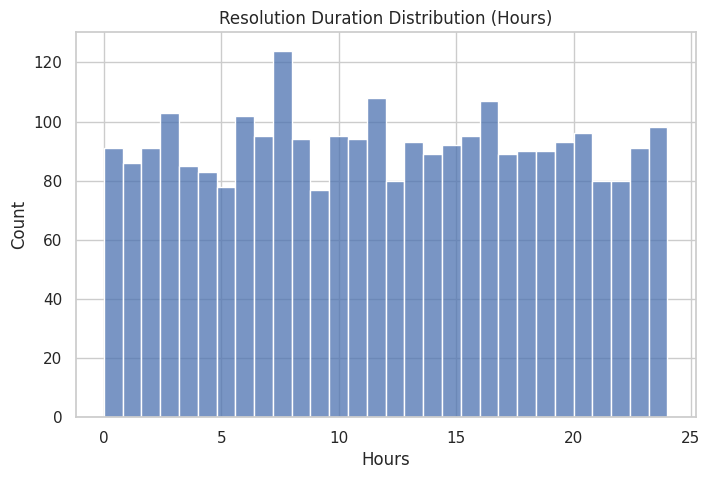

In [ ]:
sns.histplot(df['Resolution_Duration'].dropna(), bins=30)
plt.title("Resolution Duration Distribution (Hours)")
plt.xlabel("Hours")
plt.show()

## 31. Resolution Duration by Priority

Box plot comparing `Resolution_Duration` across ticket priority levels. Allows visual inspection of whether higher-priority tickets are resolved faster than lower-priority ones.

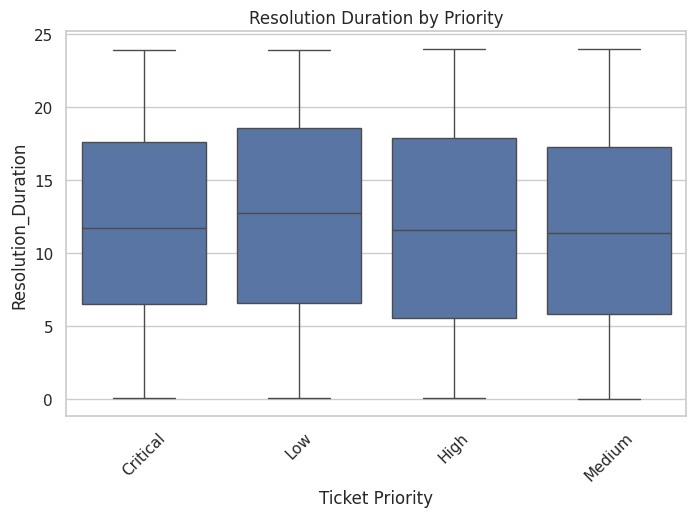

In [ ]:
sns.boxplot(data=df, x='Ticket Priority', y='Resolution_Duration')
plt.title("Resolution Duration by Priority")
plt.xticks(rotation=45)
plt.show()

## 32. Customer Satisfaction Rating Distribution

Histogram of `Customer Satisfaction Rating` (scale 1–5) for the 2,769 closed tickets. Reveals whether ratings are skewed high, low, or roughly uniform — a key KPI for support team performance.

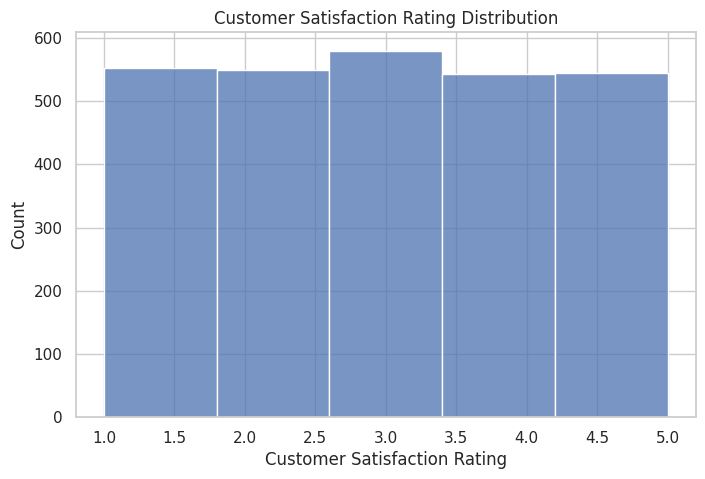

In [ ]:
sns.histplot(df['Customer Satisfaction Rating'].dropna(), bins=5)
plt.title("Customer Satisfaction Rating Distribution")
plt.show()

## 33. Correlation Matrix (Numeric Columns)

Heatmap of Pearson correlations between all numeric columns (`Ticket ID`, `Customer Age`, `Customer Satisfaction Rating`, `Resolution_Duration`, `Priority_Score`, `Cluster_ID`). Annotated with correlation coefficients; color scale ranges from dark blue (−1) to dark red (+1).

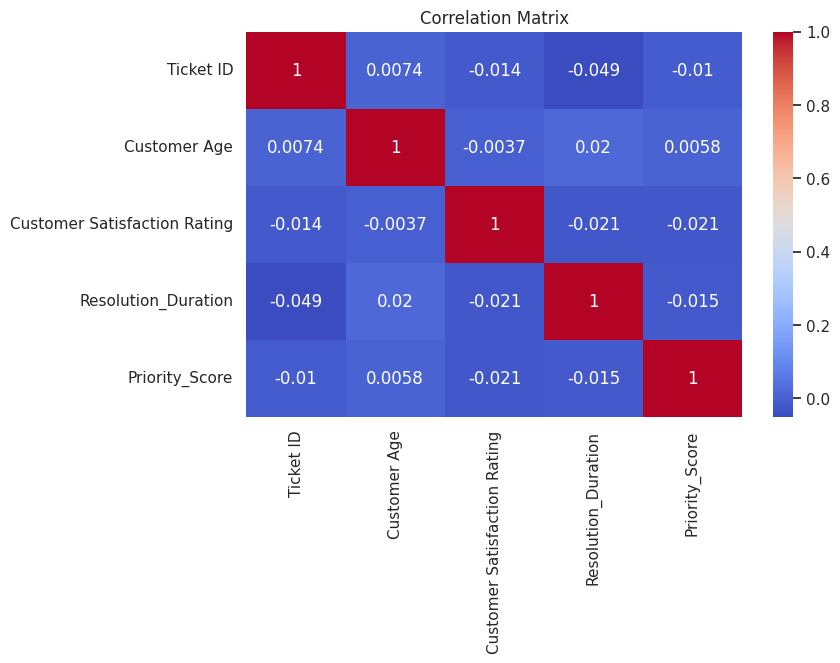

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 34. Tickets by Channel

Bar chart of ticket counts by `Ticket Channel` (Email, Chat, Phone, Social Media). Identifies which support channels receive the most volume, informing staffing and channel investment decisions.

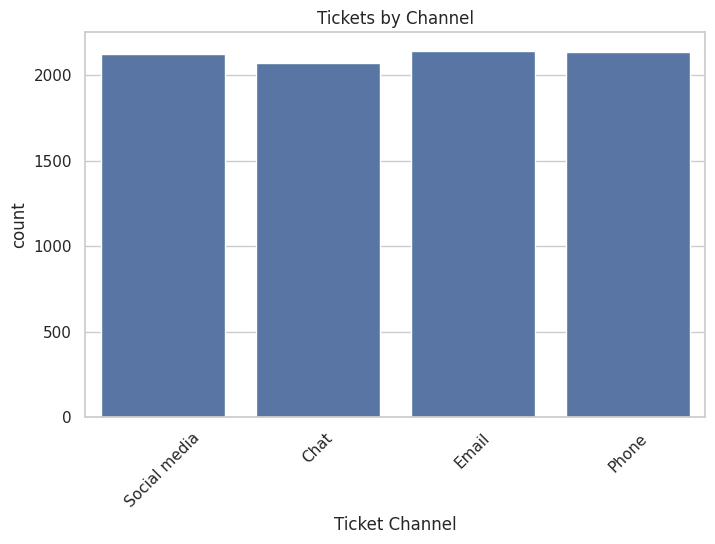

In [ ]:
sns.countplot(data=df, x='Ticket Channel')
plt.title("Tickets by Channel")
plt.xticks(rotation=45)
plt.show()

## 35. First Response Time Distribution

Histogram of the time elapsed (hours) between `Date of Purchase` and `First Response Time`. Shows how quickly the support team responds to newly submitted tickets.

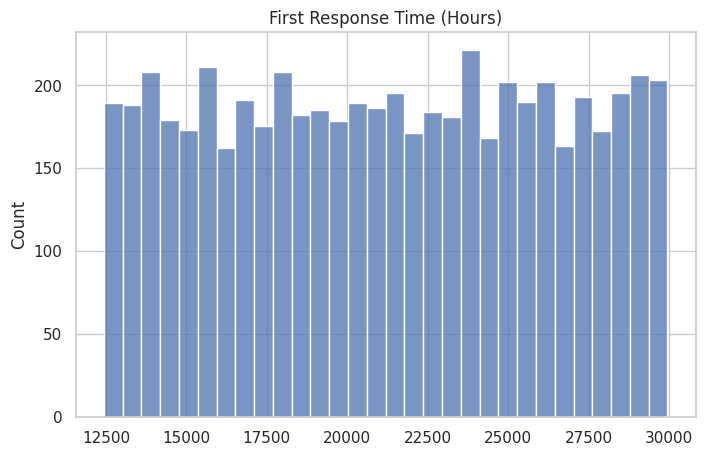

In [ ]:
response_delay = (
    df['First Response Time'] - df['Date of Purchase']
).dt.total_seconds() / 3600

sns.histplot(response_delay.dropna(), bins=30)
plt.title("First Response Time (Hours)")
plt.show()

## 36. Save Cleaned Dataset to Excel

Exports the fully processed DataFrame to an Excel file named **`Supportlytics_Cleaned_Dataset.xlsx`** without the row index. This file is ready for downstream analysis, dashboards, or sharing with stakeholders.

In [ ]:
clean_file_path = "Supportlytics_Cleaned_Dataset.xlsx"

df.to_excel(clean_file_path, index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## 37. Download Cleaned Dataset

Triggers a browser download of `Supportlytics_Cleaned_Dataset.xlsx` from the Colab runtime environment to the user's local machine.

In [ ]:
from google.colab import files
files.download(clean_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>